In [2]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from arch import arch_model

import scipy.stats as stats

import utils.Features as util

from dotenv import load_dotenv
import os

import seaborn as sns
sns.set_style(style="whitegrid")

In [3]:
load_dotenv()

START_DATE = os.getenv("START_DATE")
END_DATE = os.getenv("END_DATE")

print(START_DATE, END_DATE)

2008-01-22 2021-12-31


In [4]:
data = pd.read_csv("../Data/dataset/spy_1min_2008_2021_cleaned.csv", index_col=0, parse_dates=True)
data.head()

,open,high,low,close,volume,barCount,average
date,,,,,,,
2008-01-22 07:30:00,126.45,126.82,126.00,126.67,30987,4541,126.283
2008-01-22 07:31:00,126.67,127.17,126.39,127.12,20111,3125,126.958
2008-01-22 07:32:00,127.10,127.13,126.71,126.78,11979,2074,126.922
2008-01-22 07:33:00,126.76,126.90,126.53,126.54,8017,1350,126.675
2008-01-22 07:34:00,126.54,127.18,126.54,126.78,11967,1253,126.730


### Realized Volatility Calculation

The code calculates the total daily realized variance by combining intraday variance and overnight variance.

#### 1. Intraday Variance ($RV_{intraday}$)
The intraday variance is calculated using 5-minute returns.
$$
r_{t,i} = \ln\left(\frac{P_{t,i}}{P_{t,i-1}}\right)
$$
where $P_{t,i}$ is the close price at time interval $i$ on day $t$.

The realized intraday variance for day $t$ is the sum of squared 5-minute returns:
$$
RV_{t}^{intraday} = \sum_{i} r_{t,i}^2
$$

#### 2. Overnight Variance ($RV_{overnight}$)
The overnight return captures the gap between the previous day's close and the current day's open.
$$
r_{t}^{overnight} = \ln\left(\frac{P_{t, open}}{P_{t-1, close}}\right)
$$

The overnight variance is the squared overnight return:
$$
RV_{t}^{overnight} = (r_{t}^{overnight})^2
$$

#### 3. Total Realized Variance ($RV_{total}$)
The total daily realized variance is the sum of the intraday and overnight components:
$$
RV_{t}^{total} = RV_{t}^{intraday} + RV_{t}^{overnight}
$$

Finally, the code scales this variance to match GARCH units (multiplying by $100^2$ or $10,000$) and takes the square root to get volatility:
$$
\sigma_{t} = \sqrt{RV_{t}^{total} \times 10000}
$$


In [ ]:
# Intraday Variance
close_5mn = data.close.resample("5min").last().dropna()
rt_intraday = np.log(close_5mn / close_5mn.shift(1)).dropna()
rv_intraday = (rt_intraday ** 2).groupby(rt_intraday.index.date).sum()

# Overnight Variance
daily_ohlc = data.close.resample("1D").agg(['first', 'last']).dropna()
daily_ohlc["prev_close"] = daily_ohlc['last'].shift(1)

# Overnight returns
rt_overnight = np.log(daily_ohlc['first'] / daily_ohlc['prev_close']).dropna()
rv_overnight = rt_overnight ** 2

# Total Realized Variance
rv_total = pd.DataFrame({'intraday': rv_intraday, 'overnight': rv_overnight}).dropna()
rv_total['RV_Daily_Var'] = rv_total['intraday'] + rv_total['overnight']

# Scale to match GARCH (x100^2 = x10000)
target_variance = rv_total['RV_Daily_Var'] * 10000
target_volatility = np.sqrt(target_variance)

target_volatility.head()
target_volatility.plot(title="Daily Realized Volatility (5-min Intraday + Overnight)", figsize=(12,6))

NameError: name 'data' is not defined

: 

<Axes: title={'center': 'Daily Log Returns'}, xlabel='date'>

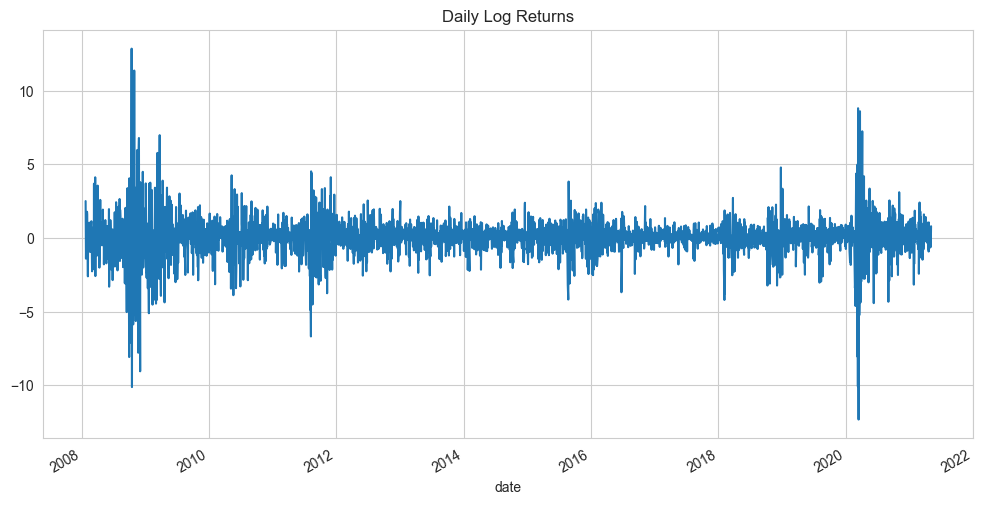

In [61]:
df_daily = data.close.resample("1D").last().dropna()
r_daily = np.log(df_daily / df_daily.shift(1)) * 100
r_daily.dropna(inplace=True)
r_daily.head()
r_daily.plot(title="Daily Log Returns", figsize=(12,6))

In [66]:
ration = .9
split_index = int(len(r_daily) * ration)
split_date = r_daily.index[split_index] 
  
print(f"Split date: {split_date}")

Split date: 2020-01-08 00:00:00


In [67]:
model = arch_model(r_daily, vol="Garch", p=1, q=1, dist="t", mean="constant")
res = model.fit(last_obs=split_date, disp="off")
print(res.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                        close   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -3882.67
Distribution:      Standardized Student's t   AIC:                           7775.34
Method:                  Maximum Likelihood   BIC:                           7805.39
                                              No. Observations:                 3011
Date:                      Tue, Jan 20 2026   Df Residuals:                     3010
Time:                              02:42:25   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

In [68]:
forecasts = res.forecast(start=split_date, method="analytic")
garch_var = pd.DataFrame(forecasts.variance.dropna())
garch_var.rename(columns={'h.1': 'GARCH_Variance_Forecast'}, inplace=True)
print(garch_var.head())

            GARCH_Variance_Forecast
date                               
2020-01-08                 0.338245
2020-01-09                 0.357134
2020-01-10                 0.339851
2020-01-13                 0.360816
2020-01-14                 0.331047


In [71]:
test_target_var = pd.DataFrame(target_variance.loc[garch_var.index])
# test_target_var.rename(columns={'h.1': 'GARCH_Variance_Forecast'}, inplace=True)
print(test_target_var.head())

            RV_Daily_Var
date                    
2020-01-08      0.264686
2020-01-09      0.793758
2020-01-10      0.189389
2020-01-13      0.137809
2020-01-14      0.177300


C:\Users\yahya\AppData\Local\Temp\ipykernel_7892\4057466402.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


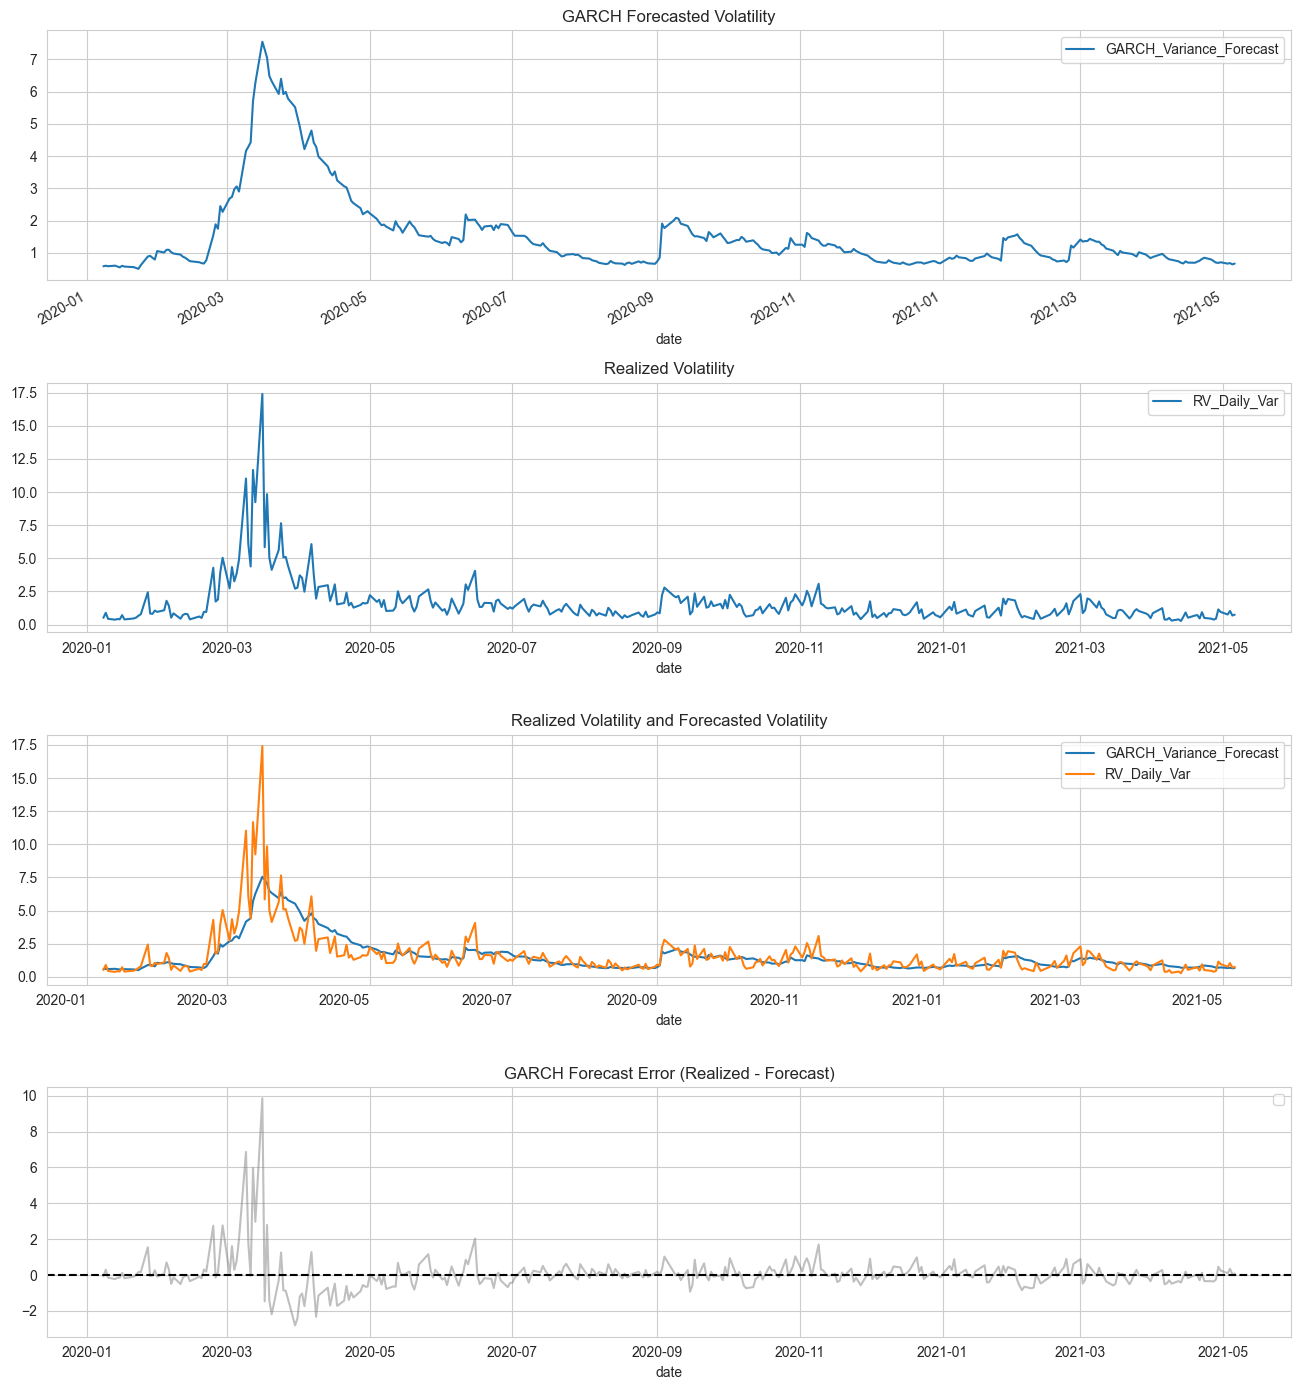

In [72]:
fig, ax = plt.subplots(4, 1, figsize=(13, 14))

np.sqrt(garch_var).plot(title="GARCH Forecasted Volatility", ax=ax[0])

np.sqrt(test_target_var).plot(title="Realized Volatility", ax=ax[1])

np.sqrt(garch_var).plot(title="Realized Volatility and Forecasted Volatility", ax=ax[2])
np.sqrt(test_target_var).plot(ax=ax[2],)


residuals = np.sqrt(test_target_var["RV_Daily_Var"]) - np.sqrt(garch_var['GARCH_Variance_Forecast'])
residuals.plot(color='gray', alpha=0.5, ax=ax[3])
ax[3].axhline(0, color='black', linestyle='--')
ax[3].set_title("GARCH Forecast Error (Realized - Forecast)")

plt.legend()
plt.tight_layout()
plt.show()

In [12]:
def q_like(realized, predicted):
    div = realized/predicted
    ql = div - np.log(div) - 1
    return np.mean(ql)

In [ ]:
print("Evaluation Metrics Naive Model:")
print("     MAE:", mean_absolute_error(np.sqrt(test_target_var).iloc[1:], np.sqrt(test_target_var).shift(1).dropna()))
print("     MSE:", mean_squared_error(np.sqrt(test_target_var).iloc[1:], np.sqrt(test_target_var).shift(1).dropna()))
print("     QLIKE:", q_like((test_target_var).iloc[1:].to_numpy(), (test_target_var).shift(1).dropna().to_numpy()))

print("Evaluation Metrics:")
print("     MAE:", mean_absolute_error(np.sqrt(test_target_var), np.sqrt(garch_var["h.1"])))
print("     MSE:", mean_squared_error(np.sqrt(test_target_var), np.sqrt(garch_var["h.1"])))
print("     QLIKE:", q_like((test_target_var).to_numpy(), (garch_var["h.1"]).to_numpy()))

Evaluation Metrics Naive Model:
     MAE: 0.6308152383024702
     MSE: 1.578871682663475
     QLIKE: 0.5076623392586975
Evaluation Metrics:
     MAE: 0.5054767048459853
     MSE: 0.9984433808890498
     QLIKE: 0.31723474339403135



In [ ]:
# Evaluation Metrics Naive Model:
#      MAE: 0.6308152383024702
#      MSE: 1.578871682663475
#      QLIKE: 0.5076623392586975
# Evaluation Metrics:
#      MAE: 0.5054767048459853
#      MSE: 0.9984433808890498
#      QLIKE: 0.31723474339403135

SyntaxError: invalid syntax (1098822319.py, line 1)